### Data Preprocessing - Panel A

#### Import Library & Input Data

In [ ]:
# Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Input data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dfA = pd.read_csv('/content/drive/MyDrive/Projects/urbansolv/_PanelAs__202505281600 new.csv')

In [ ]:
dfA.head()

,id,timestamp,flow1,turbidity,ph,tds,createdAt,updatedAt
0,392388,1970-01-01 07:34:52.135 +0700,0.0,6.682701,7.85,154.5025,2025-02-17 16:13:52.755 +0700,2025-02-17 16:13:52.755 +0700
1,392389,1970-01-01 07:34:57.134 +0700,0.0,6.687761,7.85,154.5198,2025-02-17 16:13:57.747 +0700,2025-02-17 16:13:57.747 +0700
2,392390,1970-01-01 07:35:06.931 +0700,0.0,6.691935,7.85,154.5198,2025-02-17 16:14:07.523 +0700,2025-02-17 16:14:07.523 +0700
3,392391,1970-01-01 07:35:12.283 +0700,0.0,6.685376,7.85,154.4954,2025-02-17 16:14:12.883 +0700,2025-02-17 16:14:12.883 +0700
4,392392,1970-01-01 07:35:17.283 +0700,0.0,6.679331,7.85,154.5081,2025-02-17 16:14:17.883 +0700,2025-02-17 16:14:17.883 +0700


In [ ]:
dfA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1485410 entries, 0 to 1485409
Data columns (total 8 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   id         1485410 non-null  int64  
 1   timestamp  1485410 non-null  object 
 2   flow1      1376819 non-null  float64
 3   turbidity  1485410 non-null  float64
 4   ph         1485410 non-null  float64
 5   tds        1485410 non-null  float64
 6   createdAt  1485410 non-null  object 
 7   updatedAt  1485410 non-null  object 
dtypes: float64(4), int64(1), object(3)
memory usage: 90.7+ MB


In [ ]:
pd.set_option('display.float_format', '{:.4f}'.format)
dfA.describe()

,id,flow1,turbidity,ph,tds
count,1485410.0000,1376819.0000,1485410.0000,1485410.0000,1485410.0000
mean,742705.5000,10451934552.8103,13.2383,7.1328,119.5892
std,428801.0760,8672013574036.2578,15.6289,1.6835,35.4544
min,1.0000,-91.1458,0.0000,0.0000,0.0000
25%,371353.2500,0.0000,4.0045,7.1100,111.9240
50%,742705.5000,0.0000,6.7500,7.3900,113.8089
75%,1114057.7500,0.0000,20.0730,7.8000,148.1204
max,1485410.0000,7195211000000000.0000,99.0000,10.2700,188.9343


#### Missing Value

In [ ]:
dfA.isna().sum()

,0
id,0
timestamp,0
flow1,108591
turbidity,0
ph,0
tds,0
createdAt,0
updatedAt,0


In [ ]:
dfA['flow1'].quantile([0.25, 0.5, 0.75])

,flow1
0.2500,0.0000
0.5000,0.0000
0.7500,0.0000


In [ ]:
dfA['flow1'].value_counts().sort_values(ascending=False).head()

,count
flow1,
0.0000,1171056
9.0000,13103
1.0000,13103
2.0000,13030
3.0000,12958


Hanya satu kolom yang memiliki missing value, yaitu flow1. Untuk mengatasi missing value pada kolom tsb, maka akan dilakukan imputasi data menggunakan mediannya.

In [ ]:
dfA_clean = dfA.copy()
dfA_clean['flow1'] = dfA['flow1'].fillna(dfA['flow1'].median())

In [ ]:
dfA_clean.isna().sum()

,0
id,0
timestamp,0
flow1,0
turbidity,0
ph,0
tds,0
createdAt,0
updatedAt,0


#### Duplicate Value

In [ ]:
# Mencari duplicate value dari setiap kolom
dfA_clean[dfA_clean.duplicated()]

,id,timestamp,flow1,turbidity,ph,tds,createdAt,updatedAt


Tidak ada duplicate value.

#### Outlier value

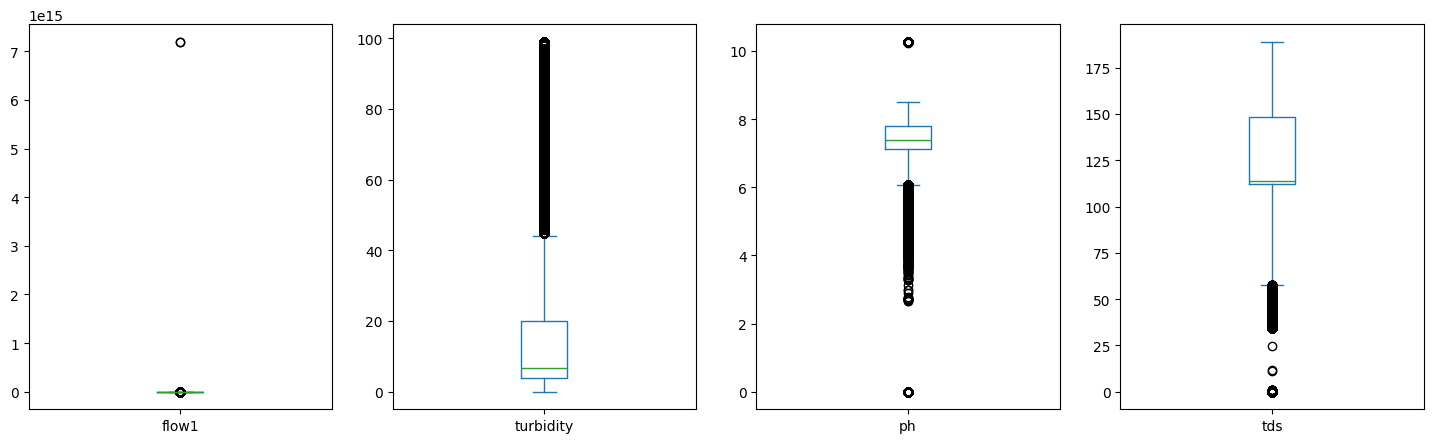

In [ ]:
# Mencari outlier data variabel numerik dengan menggunakan boxplot
float_cols = dfA_clean.select_dtypes(include=['float64']).columns
dfA_clean[float_cols].plot(subplots=True, kind='box', figsize=(18,5))
plt.show()

Terdapat outlier di setiap variabel, akan tetapi dalam kasus kualitas air, nilai outlier atau nilai ekstrem memang wajar muncul dan tidak bisa langsung dibuang tanpa alasan yang kuat. Maka, pada kasus ini, outlier tidak dihapus.

#### Target Labeling

In [ ]:
# Fungsi Target
def categorize_water(row):
    pH = row['ph']
    turb = row['turbidity']
    tds = row['tds']
    if (pH < 5.0 or pH > 9.5) and turb > 30 and tds > 1500:
        return 'Cokelat'
    if ((5.0 <= pH < 6.0) or (8.5 <= pH < 9.0)) and (15 <= turb <= 22.5) and (800 <= tds <= 1150):
        return 'Orange'
    if ((6.0 <= pH < 6.5) or (9.0 <= pH < 9.5)) and (22.5 <= turb <= 30) and (1150 <= tds <= 1500):
        return 'Biru'
    if (6.5 <= pH <= 8.0) and turb < 5 and tds < 500:
        return 'Putih'
    return 'Tidak Terdefinisi'

In [ ]:
dfA_clean['quality_label'] = dfA_clean.apply(categorize_water, axis=1)

In [ ]:
dfA_clean['quality_label'] = dfA_clean['quality_label'].replace('Tidak Terdefinisi', 'Non-Putih')
dfA_clean['quality_label'].value_counts()

,count
quality_label,
Non-Putih,1190348
Putih,295062


Setelah target labeling dilakukan, diperoleh dua label target yaitu ‘Putih’ dan Non Terdefinisi’. Label ‘Putih’ menunjukkan air memenuhi standar minimal kualitas, sedangkan label Non Putih menunjukkan air tidak memenuhi semua syarat kategori dan belum bisa dipastikan layak menurut kriteria yang digunakan.

#### Imbalance Data

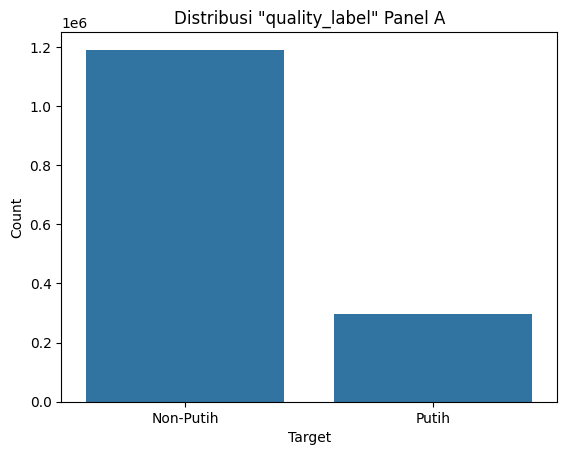

In [ ]:
target_counts = dfA_clean['quality_label'].value_counts()
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title('Distribusi "quality_label" Panel A')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

In [ ]:
dfA_clean['quality_label'].value_counts(normalize=True)

,proportion
quality_label,
Non-Putih,0.8014
Putih,0.1986


Dataset Panel A memiliki data yang tidak seimbang. Dengan demikian, akan dilakukan handling imbalance data Panel A dengan menggunakan teknik class weights saat modeling.

#### Data Distribution

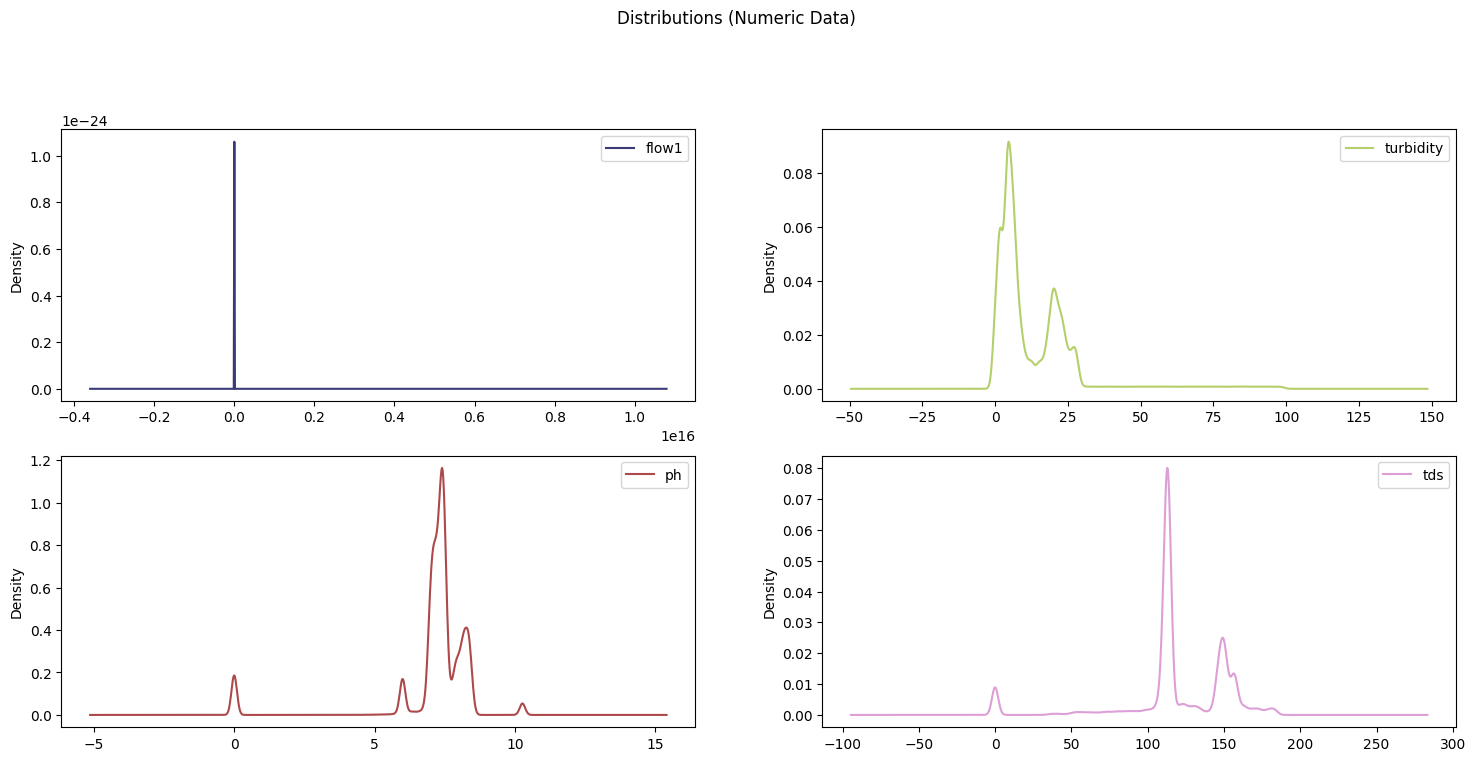

In [ ]:
dfA_clean[['flow1','turbidity','ph','tds']].plot(
    title = 'Distributions (Numeric Data)',
    kind = 'density',
    subplots = True,
    layout = (3,2),
    sharex = False,
    ylabel = False,
    figsize = (18, 12),
    colormap = 'tab20b')
plt.show()

Seluruh variabel berdistribusi tidak normal.

#### Multivariate Analysis

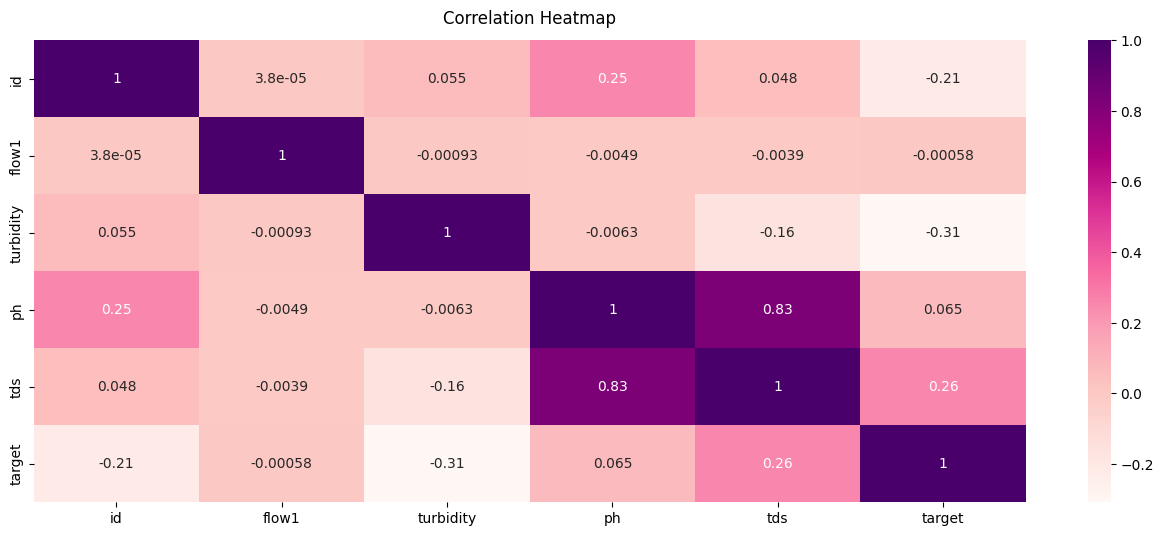

In [ ]:
from sklearn.preprocessing import LabelEncoder

dfA_mulvar = dfA_clean.copy()

# Encode target
le = LabelEncoder()
dfA_clean['target'] = le.fit_transform(dfA_clean['quality_label'])

# Pilih semua kolom numerik (termasuk yang baru)
numeric_df = dfA_clean.select_dtypes(include=['number'])

plt.figure(figsize=(16, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdPu')
plt.title('Correlation Heatmap', fontsize=12, pad=12)
plt.show()

Tidak terdapat korelasi sempurna.

### Machine Learning

#### Import Library

In [ ]:
# Modeling
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from xgboost.sklearn import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

#### Split Data

In [ ]:
dfA_ML = dfA_clean.copy()

features = ['flow1', 'turbidity', 'tds', 'ph']
X = dfA_ML[features]          # fitur
y = dfA_ML['quality_label']   # target

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)

#Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

In [ ]:
import joblib
from google.colab import files

def save_test_data(X_test, y_test_encoded, le):
    y_true_label = le.inverse_transform(y_test_encoded)
    df_test_final = X_test.copy()
    df_test_final['quality_label'] = y_true_label
    data_file_name = 'test_data_A.csv'
    df_test_final.to_csv(data_file_name, index=False)
    print(f"Data Uji berhasil disimpan: {data_file_name}")

save_test_data(X_test, y_test, le)
files.download("test_data_A.csv")

Data Uji berhasil disimpan: test_data_A.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Inisiasi Scaler
scaler = StandardScaler()

# Scaling data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Download scaler
joblib.dump(scaler, "scaler_panelA.joblib")
files.download('scaler_panelA.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Modeling

In [ ]:
# Membuat model
unique, counts = np.unique(y_train, return_counts=True)
ratio = max(counts) / min(counts)
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=ratio)
lr = LogisticRegression(random_state=42, class_weight='balanced', solver='liblinear', max_iter=1000)
sv = LinearSVC(random_state=42, class_weight='balanced', dual=False, max_iter=5000)

# List model
models = [xgb, lr, sv]
model_names = ['XGBoost', 'Logistic Regression', 'SVM']

# Dictionary untuk menyimpan hasil prediksi
y_preds = {}

# Melakukan fit training dan prediksi untuk setiap model
for model, name in zip(models, model_names):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_preds[name] = y_pred

In [ ]:
# Simpan data frame y_pred
df_preds = pd.DataFrame({
    "y_true": y_test
})
for name, preds in y_preds.items():
    df_preds[f"y_pred_{name.replace(' ', '_')}"] = preds
df_preds.head()

,y_true,y_pred_XGBoost,y_pred_Logistic_Regression,y_pred_SVM
0,0,0,1,1
1,0,0,0,0
2,0,0,0,0
3,0,0,1,1
4,1,1,1,1


In [ ]:
# Simpan model yang sudah di-fit
import joblib

# Dictionary model
model_files = {
    'XGBoost': 'modelA_xgb.joblib',
    'Logistic Regression': 'modelA_lr.joblib',
    'SVM': 'modelA_svm.joblib'
}

# Simpan model sesuai nama
for name, model in zip(model_names, models):
    filename = model_files[name]
    joblib.dump(model, filename)
    print(f"Model {name} saved as {filename}")

Model XGBoost saved as modelA_xgb.joblib
Model Logistic Regression saved as modelA_lr.joblib
Model SVM saved as modelA_svm.joblib


In [ ]:
import shutil

# Buat folder khusus dulu
import os
os.makedirs("saved_modelsA", exist_ok=True)

# Pindahkan semua file model ke folder
for name, filename in model_files.items():
    shutil.move(filename, f"saved_modelsA/{filename}")

# Zip foldernya
shutil.make_archive("models_panelA", 'zip', 'saved_modelsA')

# Download ZIP
from google.colab import files
files.download("models_panelA.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
target_names = le.classes_
results_final = []
print("\n--- ANALISIS KINERJA MODEL ---")

for name, y_pred in y_preds.items():

    # Mendapatkan Laporan Klasifikasi sebagai dictionary
    report = classification_report(y_test, y_pred,
                                   target_names=target_names,
                                   output_dict=True,
                                   zero_division=0) # zero_division=0 agar tidak error jika support 0

    # Menentukan Kelas Minoritas (untuk fokus pada metrik yang tepat)
    support_values = [report[label]['support'] for label in target_names]
    minority_index = np.argmin(support_values)
    minority_class_label = target_names[minority_index]

    # Menyimpan Metrik Penting
    results_final.append({
        'Model': name,
        'F1-Score (Weighted)': report['weighted avg']['f1-score'],
        f'Recall ({minority_class_label})': report[minority_class_label]['recall'],
        f'Precision ({minority_class_label})': report[minority_class_label]['precision'],
        f'F1-Score ({minority_class_label})': report[minority_class_label]['f1-score']
    })

    # Mencetak laporan detail untuk setiap model
    print(f"\n[Laporan Klasifikasi: {name}]")
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))


--- ANALISIS KINERJA MODEL ---

[Laporan Klasifikasi: XGBoost]
              precision    recall  f1-score   support

   Non-Putih       1.00      1.00      1.00    238070
       Putih       1.00      1.00      1.00     59012

    accuracy                           1.00    297082
   macro avg       1.00      1.00      1.00    297082
weighted avg       1.00      1.00      1.00    297082


[Laporan Klasifikasi: Logistic Regression]
              precision    recall  f1-score   support

   Non-Putih       0.98      0.76      0.86    238070
       Putih       0.50      0.94      0.65     59012

    accuracy                           0.80    297082
   macro avg       0.74      0.85      0.75    297082
weighted avg       0.88      0.80      0.82    297082


[Laporan Klasifikasi: SVM]
              precision    recall  f1-score   support

   Non-Putih       0.99      0.75      0.85    238070
       Putih       0.49      0.96      0.65     59012

    accuracy                           0.79   

#### Hyperparameter Tuning

In [ ]:
# Hyperparameter Tuning XGB
# Parameter Grid
param_grid_xgb = {
        'max_depth': [3, 5, 7],                     # Pembatasan kedalaman (penting untuk cegah overfitting)
        'learning_rate': [0.05, 0.1, 0.2],          # Kecepatan pembelajaran
        'n_estimators': [100, 200],                 # Jumlah pohon
        'gamma': [0, 0.5],                          # Regularisasi minimum loss reduction
        'reg_lambda': [0.1, 1],                     # Regularisasi L2

        # Pengaturan Imbalanced dan Teknis
        'scale_pos_weight': [ratio],
        'use_label_encoder': [False],
        'eval_metric': ['logloss'],
        'random_state': [42]
    }

# Inisialisasi Model dan GridSearchCV
xgb = XGBClassifier()

grid_search_xgb = GridSearchCV(
        estimator=xgb,
        param_grid=param_grid_xgb,
        scoring='accuracy',
        cv=5,
        n_jobs=-1,
        verbose=2
    )

# Fitting
grid_search_xgb.fit(X_train_scaled, y_train)

# Hasil Terbaik
print("Parameter Terbaik:", grid_search_xgb.best_params_)
print("Akurasi Terbaik:", grid_search_xgb.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Parameter Terbaik: {'eval_metric': 'logloss', 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'random_state': 42, 'reg_lambda': 0.1, 'scale_pos_weight': np.float64(4.0342215632281295), 'use_label_encoder': False}
Akurasi Terbaik: 0.9993814837053231


In [ ]:
# Hyperparameter Tuning Logistic Regression

# Parameter Grid
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'class_weight': ['balanced'],
    'solver': ['liblinear'], # Cocok untuk C dan class_weight='balanced'
    'max_iter': [1000],
    'random_state': [42]
}

# Inisialisasi Model dan GridSearchCV
lr = LogisticRegression()

grid_search_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Fitting
grid_search_lr.fit(X_train_scaled, y_train)

# Hasil Terbaik
print("Parameter Terbaik LR:", grid_search_lr.best_params_)
print("Akurasi Terbaik:", grid_search_lr.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Parameter Terbaik LR: {'C': 100, 'class_weight': 'balanced', 'max_iter': 1000, 'random_state': 42, 'solver': 'liblinear'}
Akurasi Terbaik: 0.7993272877211234


In [ ]:
# Hyperparameter Tuning SVC Linear

# Parameter Grid
param_grid_svc = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'class_weight': ['balanced'], # Penting untuk imbalanced data
    'dual': [False],              # Direkomendasikan ketika n_samples > n_features
    'max_iter': [5000],           # Tingkatkan iterasi untuk memastikan konvergensi
    'random_state': [42]
}

# Inisialisasi Model dan GridSearchCV
svc_linear = LinearSVC()

grid_search_svc = GridSearchCV(
    estimator=svc_linear,
    param_grid=param_grid_svc,
    scoring='accuracy',
    cv=5,               # 5-fold cross-validation
    n_jobs=-1,
    verbose=2
)

# Fitting
grid_search_svc.fit(X_train_scaled, y_train)

# Hasil Terbaik
print("Parameter Terbaik:", grid_search_svc.best_params_)
print("Akurasi Terbaik", grid_search_svc.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Parameter Terbaik: {'C': 0.001, 'class_weight': 'balanced', 'dual': False, 'max_iter': 5000, 'random_state': 42}
Akurasi Terbaik 0.7872994641222271


#### Remodeling

In [ ]:
# Remodeling
xgb_tuned = XGBClassifier(**grid_search_xgb.best_params_)
lr_tuned = LogisticRegression(**grid_search_lr.best_params_)
sv_tuned = LinearSVC(**grid_search_svc.best_params_)

# Fit data train tuned model
xgb_tuned.fit(X_train_scaled, y_train)
lr_tuned.fit(X_train_scaled, y_train)
sv_tuned.fit(X_train_scaled,y_train)

# Pred data test tuned model
y_pred_xgb_tuned = xgb_tuned.predict(X_test_scaled)
y_pred_lr_tuned = lr_tuned.predict(X_test_scaled)
y_pred_svm_tuned = sv_tuned.predict(X_test_scaled)

In [ ]:
import zipfile
from google.colab import files as gfiles

# Buat folder untuk menyimpan model
os.makedirs("tunedA_models", exist_ok=True)

# Simpan model-model tuned
joblib.dump(xgb_tuned, "xgb_tunedA.joblib")
joblib.dump(lr_tuned, "lr_tunedA.joblib")
joblib.dump(sv_tuned, "svm_tunedA.joblib")

model_files_tuned = [
    "xgb_tunedA.joblib",
    "lr_tunedA.joblib",
    "svm_tunedA.joblib"
]

for file in model_files_tuned:
    if os.path.exists(file):
        shutil.copy(file, "tunedA_models")
    else:
        print(f"File tidak ditemukan: {file}")

zip_name = "models_tunedA.zip"
with zipfile.ZipFile(zip_name, 'w') as zipf:
    for root, dirs, files_in_dir in os.walk("tunedA_models"):
        for f in files_in_dir:
            zipf.write(os.path.join(root, f))

In [ ]:
gfiles.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Tambahin ke df_preds
df_preds["y_pred_XGBoost_tuned"] = y_pred_xgb_tuned
df_preds["y_pred_LogisticRegression_tuned"] = y_pred_lr_tuned
df_preds["y_pred_SVM_tuned"] = y_pred_svm_tuned
df_preds.head()

,y_true,y_pred_XGBoost,y_pred_Logistic_Regression,y_pred_SVM,y_pred_XGBoost_tuned,y_pred_LogisticRegression_tuned,y_pred_SVM_tuned
0,0,0,1,1,0,1,1
1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0
3,0,0,1,1,0,1,1
4,1,1,1,1,1,1,1


In [ ]:
from google.colab import files
# Import CSV dan download
df_preds.to_csv('df_predsA.csv', index=False)
files.download('df_predsA.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Evaluasi Keseluruhan

##### Akurasi

In [ ]:
before = [accuracy_score(y_test, y_preds['XGBoost']),
          accuracy_score(y_test, y_preds['Logistic Regression']),
          accuracy_score(y_test, y_preds['SVM'])]
tuned = [accuracy_score(y_test, y_pred_xgb_tuned),
         accuracy_score(y_test, y_pred_lr_tuned),
         accuracy_score(y_test, y_pred_svm_tuned)]

before_formatted = [f'{score:.8f}' for score in before]
tuned_formatted = [f'{score:.8f}' for score in tuned]

acc_df = pd.DataFrame(data={
    'Model Name': model_names,
    'Before Tuning': before_formatted,
    'After Tuning': tuned_formatted
    })

#acc_df.set_index('Model Name', inplace=True)
acc_df

,Model Name,Before Tuning,After Tuning
0,XGBoost,0.99948162,0.99948162
1,Logistic Regression,0.79923388,0.79929784
2,SVM,0.79444396,0.78872500


In [ ]:
# DOwnload
acc_df.to_csv('acc_dfA.csv')
files.download('acc_dfA.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##### Train-Test Evaluation

In [ ]:
import joblib

In [ ]:
# XGB
# Load model
model = joblib.load("modelA_xgb.joblib")
a = model.predict(X_train_scaled)
b = model.predict(X_test_scaled)

train_acc = accuracy_score(y_train, a)
test_acc = accuracy_score(y_test, b)

print("XGB Model")
print("Train Accuracy :", train_acc)
print("Test Accuracy  :", test_acc)
print(f"Gap Accuracy : {abs(test_acc-train_acc):.10f}")

XGB Model
Train Accuracy : 0.9994092540106772
Test Accuracy  : 0.9994816246019618
Gap Accuracy : 0.0000723706


In [ ]:
# Logistic Regression
# Load model
model = joblib.load("lr_tunedA.joblib")
a = model.predict(X_train_scaled)
b = model.predict(X_test_scaled)

train_acc = accuracy_score(y_train, a)
test_acc = accuracy_score(y_test, b)

print("Logistic Regression")
print("Train Accuracy :", train_acc)
print("Test Accuracy  :", test_acc)
print(f"Gap Accuracy : {abs(test_acc-train_acc):.10f}")

Logistic Regression
Train Accuracy : 0.7993407544045078
Test Accuracy  : 0.7992978369608391
Gap Accuracy : 0.0000429174


In [ ]:
# SVM
# Load model
model = joblib.load("modelA_svm.joblib")
a = model.predict(X_train_scaled)
b = model.predict(X_test_scaled)

train_acc = accuracy_score(y_train, a)
test_acc = accuracy_score(y_test, b)

print("SVM")
print("Train Accuracy :", train_acc)
print("Test Accuracy  :", test_acc)
print(f"Gap Accuracy : {abs(test_acc-train_acc):.10f}")

SVM
Train Accuracy : 0.7947292330063753
Test Accuracy  : 0.7944439582337537
Gap Accuracy : 0.0002852748


Tiga model terbaik yang diambil memiliki gap akurasi yang kecil, artinya model tidak mengalami overfitting.

##### Confusion Matrix

In [ ]:
# Membuat classification report
print('XGB Model')
print('### Testing Results Before Tuning ###\n')
print(classification_report(y_test, y_preds['XGBoost'], target_names=target_names), '\n')

print('### Testing Results After Tuning ###\n')
print(classification_report(y_test, y_pred_xgb_tuned, target_names=target_names), '\n')

XGB Model
### Testing Results Before Tuning ###

              precision    recall  f1-score   support

   Non-Putih       1.00      1.00      1.00    238070
       Putih       1.00      1.00      1.00     59012

    accuracy                           1.00    297082
   macro avg       1.00      1.00      1.00    297082
weighted avg       1.00      1.00      1.00    297082
 

### Testing Results After Tuning ###

              precision    recall  f1-score   support

   Non-Putih       1.00      1.00      1.00    238070
       Putih       1.00      1.00      1.00     59012

    accuracy                           1.00    297082
   macro avg       1.00      1.00      1.00    297082
weighted avg       1.00      1.00      1.00    297082
 



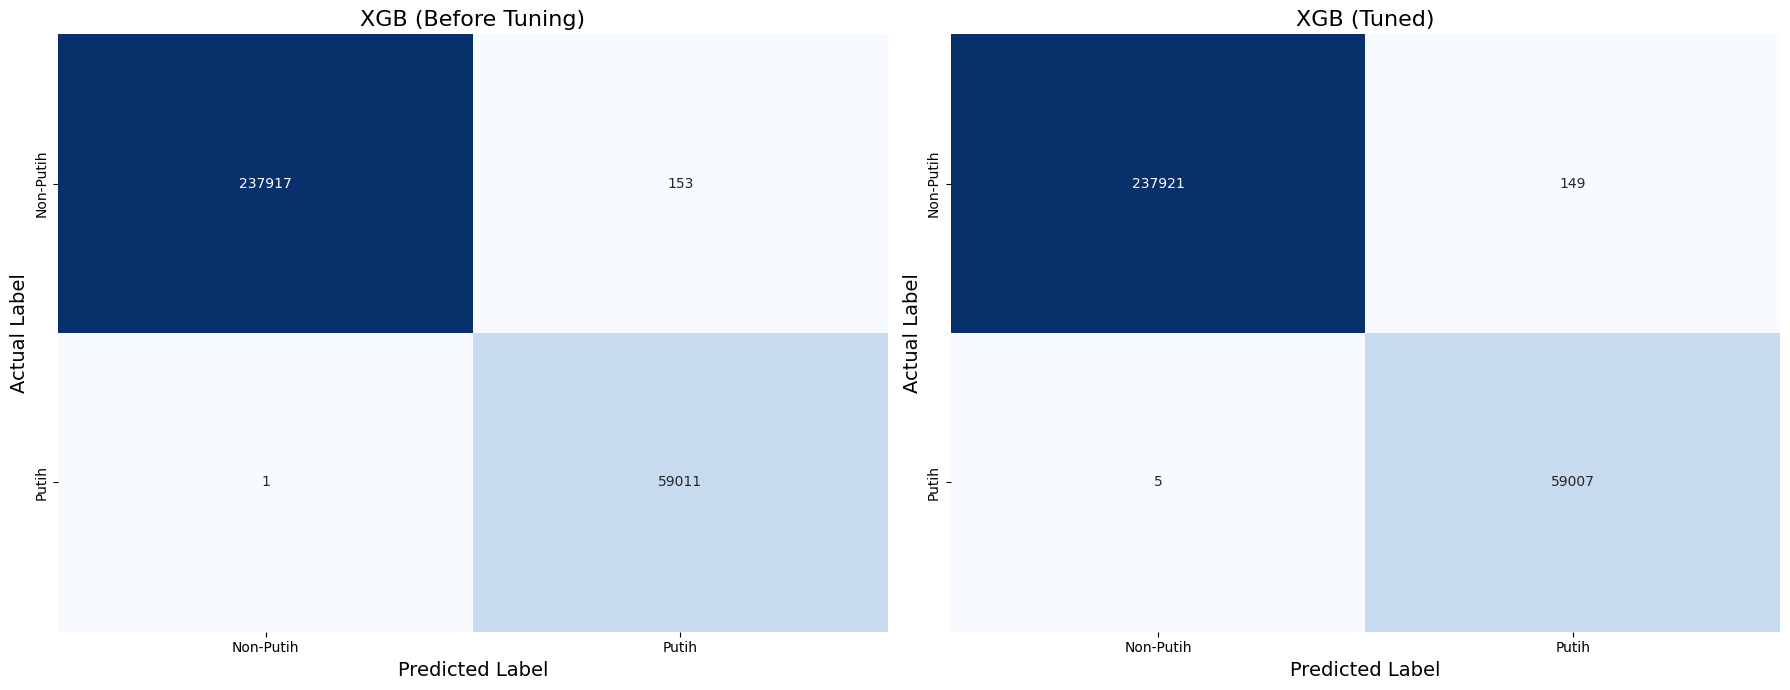

In [ ]:
# Definisikan pasangan model dan prediksi yang baru
model_titles = ['XGB (Before Tuning)', 'XGB (Tuned)']
predictions = [
    y_preds['XGBoost'],
    y_pred_xgb_tuned
]

# Membuat figure dan subplot grid (1 baris, 2 kolom)
fig, axs = plt.subplots(1, 2, figsize=(18, 7))
axs = axs.flatten()

# Iterasi dan plot Confusion Matrices
for i, title in enumerate(model_titles):
    ax = axs[i]
    matrix = confusion_matrix(y_test, predictions[i])
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        cbar=False,
        xticklabels=target_names,
        yticklabels=target_names
    )
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Predicted Label', fontsize=14)
    ax.set_ylabel('Actual Label', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
# Membuat classification report
print('Logistic Regression Model')
print('### Testing Results Before Tuning ###\n')
print(classification_report(y_test, y_preds['Logistic Regression'], target_names=target_names), '\n')

print('### Testing Results After Tuning ###\n')
print(classification_report(y_test, y_pred_lr_tuned, target_names=target_names), '\n')

Logistic Regression Model
### Testing Results Before Tuning ###

              precision    recall  f1-score   support

   Non-Putih       0.98      0.76      0.86    238070
       Putih       0.50      0.94      0.65     59012

    accuracy                           0.80    297082
   macro avg       0.74      0.85      0.75    297082
weighted avg       0.88      0.80      0.82    297082
 

### Testing Results After Tuning ###

              precision    recall  f1-score   support

   Non-Putih       0.98      0.76      0.86    238070
       Putih       0.50      0.94      0.65     59012

    accuracy                           0.80    297082
   macro avg       0.74      0.85      0.75    297082
weighted avg       0.88      0.80      0.82    297082
 



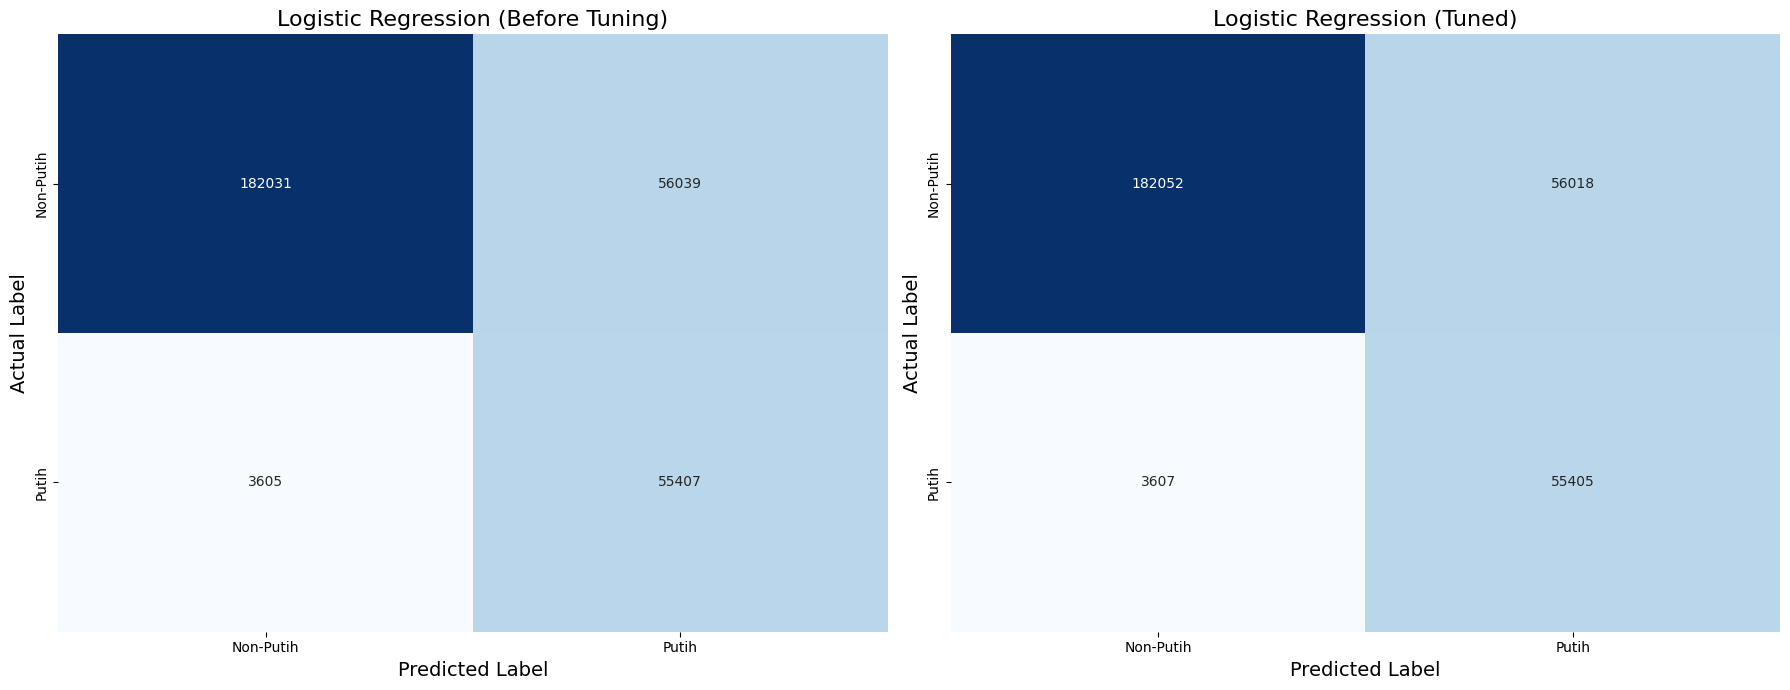

In [ ]:
# Definisikan pasangan model dan prediksi yang baru
model_titles = ['Logistic Regression (Before Tuning)', 'Logistic Regression (Tuned)']
predictions = [
    y_preds['Logistic Regression'],
    y_pred_lr_tuned
]

# Membuat figure dan subplot grid (1 baris, 2 kolom)
fig, axs = plt.subplots(1, 2, figsize=(18, 7))
axs = axs.flatten()

# Iterasi dan plot Confusion Matrices
for i, title in enumerate(model_titles):
    ax = axs[i]
    matrix = confusion_matrix(y_test, predictions[i])
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        cbar=False,
        xticklabels=target_names,
        yticklabels=target_names
    )
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Predicted Label', fontsize=14)
    ax.set_ylabel('Actual Label', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
# Membuat classification report
print('SVM Linear Model')
print('### Testing Results Before Tuning ###\n')
print(classification_report(y_test, y_preds['SVM'], target_names=target_names), '\n')

print('### Testing Results After Tuning ###\n')
print(classification_report(y_test, y_pred_svm_tuned, target_names=target_names), '\n')

SVM Linear Model
### Testing Results Before Tuning ###

              precision    recall  f1-score   support

   Non-Putih       0.99      0.75      0.85    238070
       Putih       0.49      0.96      0.65     59012

    accuracy                           0.79    297082
   macro avg       0.74      0.86      0.75    297082
weighted avg       0.89      0.79      0.81    297082
 

### Testing Results After Tuning ###

              precision    recall  f1-score   support

   Non-Putih       0.99      0.75      0.85    238070
       Putih       0.48      0.96      0.64     59012

    accuracy                           0.79    297082
   macro avg       0.74      0.85      0.75    297082
weighted avg       0.89      0.79      0.81    297082
 



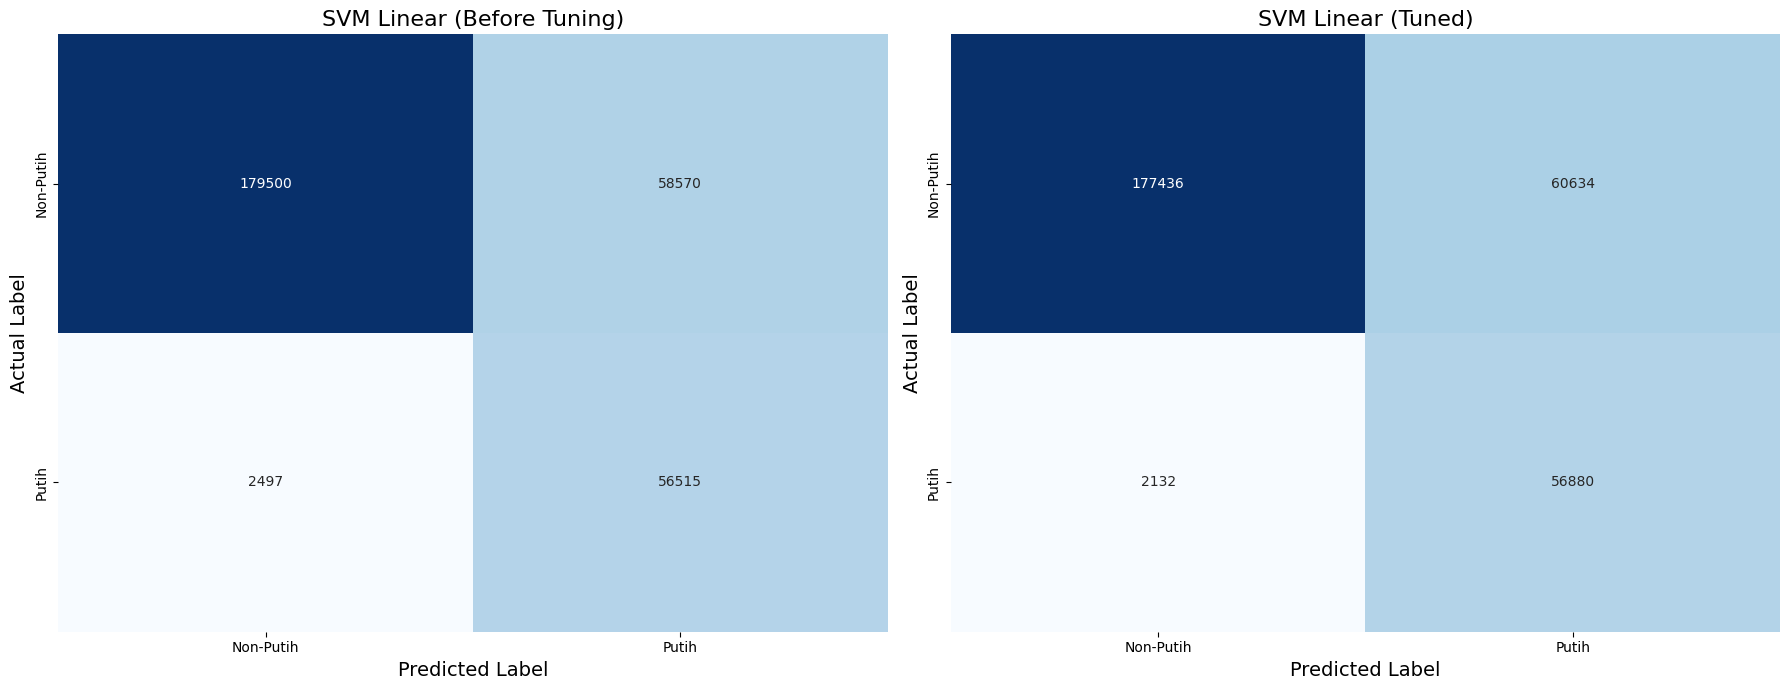

In [ ]:
# Definisikan pasangan model dan prediksi yang baru
model_titles = ['SVM Linear (Before Tuning)', 'SVM Linear (Tuned)']
predictions = [
    y_preds['SVM'],
    y_pred_svm_tuned
]

# Membuat figure dan subplot grid (1 baris, 2 kolom)
fig, axs = plt.subplots(1, 2, figsize=(18, 7))
axs = axs.flatten()

# Iterasi dan plot Confusion Matrices
for i, title in enumerate(model_titles):
    ax = axs[i]
    matrix = confusion_matrix(y_test, predictions[i])
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        cbar=False,
        xticklabels=target_names,
        yticklabels=target_names
    )
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Predicted Label', fontsize=14)
    ax.set_ylabel('Actual Label', fontsize=14)

plt.tight_layout()
plt.show()

XGB After Tuning, LR After Tuning, SVM Before Tuning

In [ ]:
report_string_XGB = classification_report(y_test, y_preds['XGBoost'], target_names=target_names, output_dict=True)
report_string_LR = classification_report(y_test, y_preds['Logistic Regression'], target_names=target_names, output_dict=True)
report_string_SVM = classification_report(y_test, y_preds['SVM'], target_names=target_names, output_dict=True)
report_string_XGB_tuned = classification_report(y_test, y_pred_xgb_tuned, target_names=target_names, output_dict=True)
report_string_LR_tuned = classification_report(y_test, y_pred_lr_tuned, target_names=target_names, output_dict=True)
report_string_SVM_tuned = classification_report(y_test, y_pred_svm_tuned, target_names=target_names, output_dict=True)

df_report_XGB = pd.DataFrame(report_string_XGB).transpose()
df_report_LR = pd.DataFrame(report_string_LR).transpose()
df_report_SVM = pd.DataFrame(report_string_SVM).transpose()
df_report_XGB_tuned = pd.DataFrame(report_string_XGB_tuned).transpose()
df_report_LR_tuned = pd.DataFrame(report_string_LR_tuned).transpose()
df_report_SVM_tuned = pd.DataFrame(report_string_SVM_tuned).transpose()

df_report_XGB.to_csv('report_XGB.csv')
df_report_LR.to_csv('report_LR.csv')
df_report_SVM.to_csv('report_SVM.csv')
df_report_XGB_tuned.to_csv('report_XGB_tuned.csv')
df_report_LR_tuned.to_csv('report_LR_tuned.csv')
df_report_SVM_tuned.to_csv('report_SVM_tuned.csv')

print("Selesai")

Selesai


In [ ]:
files.download('report_XGB.csv')
files.download('report_LR.csv')
files.download('report_SVM.csv')
files.download('report_XGB_tuned.csv')
files.download('report_LR_tuned.csv')
files.download('report_SVM_tuned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Kesimpulan

Dipilih model XGB Tuned.